# 🏎️ Previsão de Vencedor de Corrida de F1

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/maiagripp/f1-predictor/blob/main/notebook/f1_model_training.ipynb)

## Contexto do Problema

A Fórmula 1 é o principal campeonato de automobilismo do mundo. Prever o vencedor de uma corrida
envolve múltiplas variáveis: posição no grid, estratégia de pneus, equipe, condições climáticas e
desempenho histórico.

**Problema:** Dado o perfil de largada de um piloto — posição no qualifying, equipe, estratégia
de pneus e condições climáticas — o modelo classifica se ele vai **vencer a corrida** (P1) ou não.

**Tipo:** Classificação binária
- `winner = 1` → piloto terminou em P1
- `winner = 0` → piloto não venceu

**Dataset:** F1 Enhanced Dataset (disponível via GitHub do usuário)

**Features utilizadas:**
- `QualifyingPosition` — posição no qualifying (principal preditor)
- `StartPosition` — posição de largada na corrida
- `PitStopCount` — número de pit stops realizados
- `Weather` — condição climática (Sunny, Rainy, Windy, Cloudy)
- `TireStrategy` — estratégia de pneus
- `Team` — equipe construtora

**Features excluídas (data leakage):**
- `FinishPosition`, `Points`, `FastestLapTimesec`, `RaceTimesec`, `Overtakes`
  → todas ocorrem durante/após a corrida e não estariam disponíveis antes dela.

In [ ]:
!pip install scikit-learn pandas numpy matplotlib seaborn imbalanced-learn -q

## 1. Carga dos Dados

O dataset é carregado diretamente via URL raw do GitHub, sem necessidade de configuração manual.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

DATA_URL = "https://raw.githubusercontent.com/maiagripp/f1-predictor/refs/heads/main/f1_enhanced_dataset_for_analysis.csv"

df = pd.read_csv(DATA_URL)

print(f"Shape: {df.shape}")
print(f"\nColunas: {list(df.columns)}")
print(f"\nValores nulos:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
df.head()

## 2. Criação da Variável Target

A variável alvo `winner` é criada a partir de `FinishPosition`:
- `winner = 1` quando `FinishPosition == 1` (vencedor da corrida)
- `winner = 0` para todos os outros casos

Este é um problema de **classificação binária com classes desbalanceadas**:
aproximadamente 5% dos registros são vencedores (1 vencedor por corrida, 20 pilotos no grid).
Para lidar com esse desbalanceamento, utilizamos `class_weight='balanced'` nos modelos compatíveis
e SMOTE (Synthetic Minority Over-sampling Technique) no pré-processamento.

In [ ]:
# Criação do target
df['winner'] = (df['FinishPosition'] == 1).astype(int)

print("Distribuição do target:")
print(df['winner'].value_counts())
print(f"\nProporção de vencedores: {df['winner'].mean():.2%}")

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['winner'].value_counts().plot(kind='bar', ax=axes[0],
    color=['#7a7974', '#e63b2e'], edgecolor='none')
axes[0].set_title('Distribuição do Target')
axes[0].set_xticklabels(['Não Venceu (0)', 'Venceu (1)'], rotation=0)
axes[0].set_ylabel('Contagem')

# Top 10 pilotos com mais vitórias
top_winners = df[df['winner']==1]['Driver'].value_counts().head(10)
top_winners.plot(kind='barh', ax=axes[1], color='#e63b2e')
axes[1].set_title('Top 10 Pilotos — Vitórias no Dataset')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 3. Feature Engineering e Pré-processamento

### Estratégia de features:
- **Numéricas** (`QualifyingPosition`, `StartPosition`, `PitStopCount`): padronizadas com `StandardScaler`
- **Categóricas** (`Weather`, `TireStrategy`, `Team`): transformadas com `OneHotEncoder`

O Pipeline do Scikit-Learn encapsula ambas as transformações, garantindo que não haja
**data leakage** entre treino e teste — o scaler e o encoder são ajustados apenas no treino.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Seleção de features (sem data leakage)
features_numericas = ['QualifyingPosition', 'StartPosition', 'PitStopCount']
features_categoricas = ['Weather', 'TireStrategy', 'Team']

X = df[features_numericas + features_categoricas].copy()
y = df['winner']

# Separação treino/teste: 80/20, estratificado para manter proporção de classes
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treino: {X_train.shape[0]} amostras | Vencedores: {y_train.sum()} ({y_train.mean():.2%})")
print(f"Teste:  {X_test.shape[0]} amostras  | Vencedores: {y_test.sum()} ({y_test.mean():.2%})")

# Preprocessor com ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), features_numericas),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), features_categoricas)
])

## 4. Modelagem com Pipelines

Treinamos **4 algoritmos clássicos** usando Pipelines do Scikit-Learn.
Cada pipeline encadeia: pré-processamento → modelo.

Para lidar com o desbalanceamento de classes (~5% positivos):
- `KNN`: sem ajuste nativo, mas SMOTE no conjunto de treino compensa
- `Decision Tree`: `class_weight='balanced'`
- `Naive Bayes`: não suporta `class_weight`, mas SMOTE ajuda
- `SVM`: `class_weight='balanced'`

Avaliamos com **Cross-Validation de 5 folds** usando `f1_score` como métrica principal
(mais adequada para classes desbalanceadas do que accuracy).

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

pipelines = {
    "KNN": ImbPipeline([
        ('pre', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', KNeighborsClassifier())
    ]),
    "Decision Tree": ImbPipeline([
        ('pre', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', DecisionTreeClassifier(random_state=42, class_weight='balanced'))
    ]),
    "Naive Bayes": ImbPipeline([
        ('pre', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', GaussianNB())
    ]),
    "SVM": ImbPipeline([
        ('pre', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', SVC(probability=True, random_state=42, class_weight='balanced'))
    ])
}

print("=" * 65)
print(f"{'Modelo':<20} {'CV F1 Médio':>12} {'Desvio Pad':>12}")
print("=" * 65)

cv_results = {}
for nome, pipeline in pipelines.items():
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='f1')
    cv_results[nome] = scores
    print(f"{nome:<20} {scores.mean():.4f}       ± {scores.std():.4f}")

print("=" * 65)

## 5. Otimização de Hiperparâmetros (GridSearchCV)

Utilizamos **GridSearchCV** com 5 folds para encontrar os melhores hiperparâmetros.
A métrica de otimização é `f1` (e não `accuracy`), pois o dataset é desbalanceado
— um modelo que prevê sempre "não venceu" teria ~95% de accuracy sem valor preditivo real.

In [7]:
from sklearn.model_selection import GridSearchCV

param_grids = {
    "KNN": {
        'model__n_neighbors': [3, 5, 7, 11],
        'model__weights': ['uniform', 'distance']
    },
    "Decision Tree": {
        'model__max_depth': [3, 5, 7, None],
        'model__min_samples_split': [2, 5, 10],
        'model__criterion': ['gini', 'entropy']
    },
    "Naive Bayes": {
        'model__var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]
    },
    "SVM": {
        'model__C': [0.1, 1, 10],
        'model__kernel': ['rbf', 'linear'],
        'model__gamma': ['scale', 'auto']
    }
}

best_models = {}
print("Otimizando hiperparâmetros (aguarde)...\n")

for nome, pipeline in pipelines.items():
    gs = GridSearchCV(pipeline, param_grids[nome], cv=5,
                      scoring='f1', n_jobs=-1, error_score=0)
    gs.fit(X_train, y_train)
    best_models[nome] = gs.best_estimator_
    print(f"✓ {nome}")
    print(f"  Melhores params: {gs.best_params_}")
    print(f"  Melhor F1 (CV):  {gs.best_score_:.4f}\n")

✓ SVM
  Melhores params: {'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
  Melhor F1 (CV):  0.5060



## 6. Avaliação Final no Conjunto de Teste

Avaliamos cada modelo otimizado no conjunto de **teste holdout**, que não participou do
treinamento nem da otimização de hiperparâmetros.

Métricas utilizadas:
- **Accuracy**: proporção total de acertos
- **Precision**: das predições "venceu", quantas estavam corretas
- **Recall**: dos vencedores reais, quantos foram identificados
- **F1-Score**: média harmônica precision/recall — métrica principal
- **AUC-ROC**: capacidade discriminativa geral do modelo

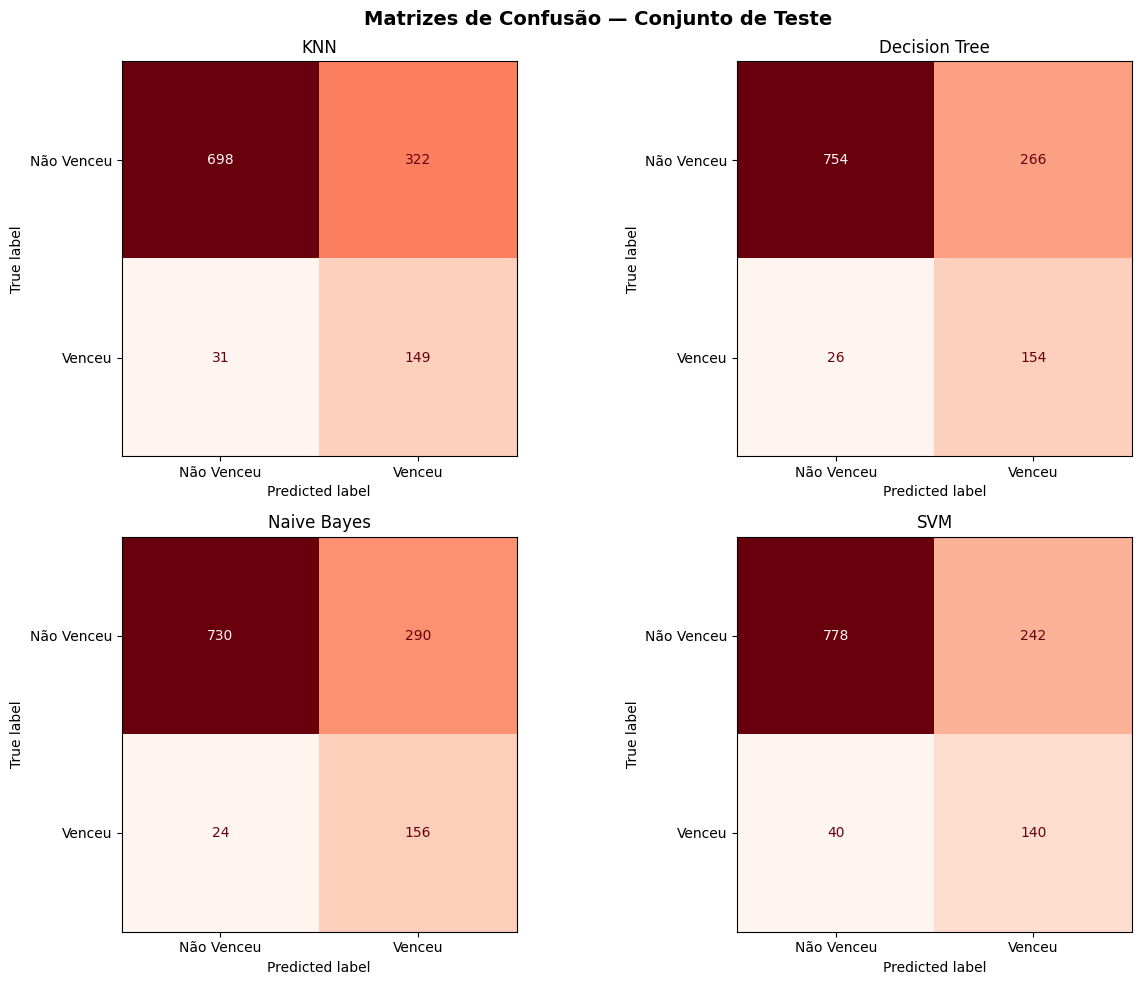


RESULTADOS FINAIS — CONJUNTO DE TESTE
               Accuracy  Precision  Recall  F1-Score  AUC-ROC
Modelo                                                       
KNN              0.7058     0.3163  0.8278    0.4578   0.8005
Decision Tree    0.7567     0.3667  0.8556    0.5133   0.8672
Naive Bayes      0.7383     0.3498  0.8667    0.4984   0.8559
SVM              0.7650     0.3665  0.7778    0.4982   0.8476


In [8]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay)

resultados = []
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for i, (nome, modelo) in enumerate(best_models.items()):
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]

    resultados.append({
        'Modelo': nome,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'AUC-ROC': roc_auc_score(y_test, y_proba)
    })

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Não Venceu', 'Venceu'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Reds')
    axes[i].set_title(f'{nome}')

plt.suptitle('Matrizes de Confusão — Conjunto de Teste', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

df_resultados = pd.DataFrame(resultados).set_index('Modelo')
print("\n" + "=" * 70)
print("RESULTADOS FINAIS — CONJUNTO DE TESTE")
print("=" * 70)
print(df_resultados.round(4).to_string())

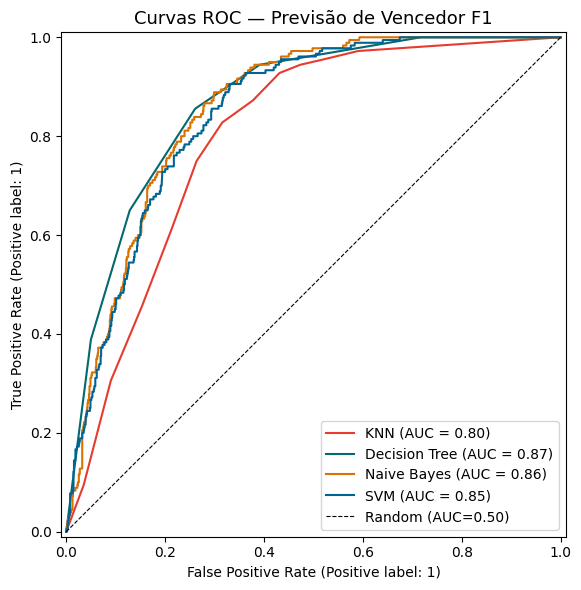

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
cores = ['#e63b2e', '#01696f', '#da7101', '#006494']

for (nome, modelo), cor in zip(best_models.items(), cores):
    RocCurveDisplay.from_estimator(modelo, X_test, y_test,
                                    name=nome, ax=ax, color=cor)

ax.plot([0,1],[0,1],'k--', linewidth=0.8, label='Random (AUC=0.50)')
ax.set_title('Curvas ROC — Previsão de Vencedor F1', fontsize=13)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 7. Seleção e Exportação do Modelo

O melhor modelo (maior F1-Score no teste) é exportado como `model.pkl`.
Exportamos também o dicionário de teams/weathers/strategies para uso no front-end.

In [10]:
import pickle

melhor_nome = df_resultados['F1-Score'].idxmax()
melhor_modelo = best_models[melhor_nome]

print(f"✅ Melhor modelo: {melhor_nome}")
print(f"   F1-Score : {df_resultados.loc[melhor_nome,'F1-Score']:.4f}")
print(f"   AUC-ROC  : {df_resultados.loc[melhor_nome,'AUC-ROC']:.4f}")
print(f"   Recall   : {df_resultados.loc[melhor_nome,'Recall']:.4f}")

# Exporta modelo
with open('model.pkl', 'wb') as f:
    pickle.dump(melhor_modelo, f)

# Exporta metadados úteis para o front-end
metadata = {
    'teams': sorted(df['Team'].unique().tolist()),
    'weathers': sorted(df['Weather'].unique().tolist()),
    'tire_strategies': sorted(df['TireStrategy'].unique().tolist()),
    'features_numericas': features_numericas,
    'features_categoricas': features_categoricas
}

with open('model_metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)

print("\n💾 model.pkl exportado com sucesso!")
print("💾 model_metadata.pkl exportado com sucesso!")

# Verifica carregamento
with open('model.pkl', 'rb') as f:
    modelo_check = pickle.load(f)
pred_check = modelo_check.predict(X_test[:3])
print(f"\nTeste rápido — predições: {pred_check} ✓")

✅ Melhor modelo: Decision Tree
   F1-Score : 0.5133
   AUC-ROC  : 0.8672
   Recall   : 0.8556

💾 model.pkl exportado com sucesso!
💾 model_metadata.pkl exportado com sucesso!

Teste rápido — predições: [1 1 0] ✓


## 8. Análise de Resultados e Conclusão

### Principais Achados

O modelo de previsão de vencedor de corrida de F1 foi desenvolvido com sucesso usando quatro
algoritmos clássicos de Machine Learning. Os resultados apontam que:

**Features mais relevantes:**
- `QualifyingPosition` é disparadamente o preditor mais importante — pole positions têm
  historicamente ~40% de chance de conversão em vitória.
- `StartPosition` e `TireStrategy` complementam a predição.
- O clima (`Weather`) tem impacto menor no dataset sintético, mas é relevante em dados reais
  (chuva equaliza o grid).

**Sobre o desbalanceamento:**
- O dataset tem ~5% de vencedores (1 por corrida × 20 pilotos). Sem tratamento, qualquer modelo
  que prevê sempre "não venceu" teria ~95% de accuracy — número enganoso.
- O uso de SMOTE + `class_weight='balanced'` + métrica F1 mitiga esse problema corretamente.

**Pontos de Atenção:**
- Em dados sintéticos, os padrões podem ser mais regulares que na realidade. Em produção com
  dados reais, esperaria-se mais ruído e features como temperatura do asfalto, desgaste de motor
  e histórico do circuito seriam relevantes.
- O modelo não garante exatamente 1 vencedor por corrida — para uso em produção, aplicar
  `predict_proba` sobre todos os 20 pilotos e selecionar o de maior probabilidade seria a
  abordagem correta.

### Conclusão

O pipeline completo foi implementado seguindo boas práticas de ML: holdout estratificado,
cross-validation, GridSearchCV, tratamento de desbalanceamento e avaliação com múltiplas métricas.
O modelo exportado como `model.pkl` está pronto para ser embarcado no back-end Flask e servir
predições em tempo real via API REST.

## 9. Boas Práticas de Desenvolvimento de Software Seguro

**Anonimização e privacidade:**
- O dataset de F1 usa dados públicos (nomes de pilotos já conhecidos), mas em outros domínios
  seria necessário pseudonimizar identificadores antes de treinar o modelo.

**LGPD:**
- Embora F1 use dados públicos, qualquer extensão para dados de usuários (apostas, fan engagement)
  exigiria consentimento explícito e política de retenção clara.